In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0,yes,southwest,16884.92400
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1337, 7)

In [5]:
df.dtypes

,0
age,float64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [6]:
# Features
X = df.drop("charges", axis=1)

# Regression Target
y_reg = df["charges"]

In [7]:
X.head()

,age,sex,bmi,children,smoker,region
0,19.0,female,27.900,0,yes,southwest
1,18.0,male,33.770,1,no,southeast
2,28.0,male,33.000,3,no,southeast
3,33.0,male,22.705,0,no,northwest
4,32.0,male,28.880,0,no,northwest


In [8]:
y_reg.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [9]:
y_clf = (y_reg > y_reg.median()).astype(int)

In [10]:
y_clf.head()

,charges
0,1
1,0
2,0
3,1
4,0


In [11]:
y_clf.value_counts()

,count
charges,
0,670
1,667


In [12]:
y_clf.value_counts()

,count
charges,
0,670
1,667


In [13]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0,False,True,False,False,True
1,18.0,33.770,1,True,False,False,True,False
2,28.0,33.000,3,True,False,False,True,False
3,33.0,22.705,0,True,False,True,False,False
4,32.0,28.880,0,True,False,True,False,False


In [14]:
X.columns

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [15]:
X.shape

(1337, 8)

In [17]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X,y_reg,test_size=0.2,random_state=42)

In [18]:
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(X,y_clf,test_size=0.2,random_state=42)

In [19]:
print("Regression Training Features :", X_train.shape)
print("Regression Testing Features  :", X_test.shape)

print("Classification Training Features :", X_train_clf.shape)
print("Classification Testing Features  :", X_test_clf.shape)

Regression Training Features : (1069, 8)
Regression Testing Features  : (268, 8)
Classification Training Features : (1069, 8)
Classification Testing Features  : (268, 8)


In [20]:
scaler = StandardScaler()

In [21]:
scaler.fit(X_train)

StandardScaler()

In [22]:
X_train_scaled = scaler.transform(X_train)

In [23]:
X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_clf_scaled = scaler.transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

In [25]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(X_train_clf_scaled.shape)
print(X_test_clf_scaled.shape)

(1069, 8)
(268, 8)
(1069, 8)
(268, 8)


In [26]:
linear_model = LinearRegression()

In [27]:
linear_model.fit(X_train_scaled, y_reg_train)

LinearRegression()

In [28]:
y_pred_reg = linear_model.predict(X_test_scaled)

In [29]:
mse = mean_squared_error(y_reg_test, y_pred_reg)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 36092828.49634034


In [30]:
r2 = r2_score(y_reg_test, y_pred_reg)

print("R² Score:", r2)

R² Score: 0.8030868639465651


In [31]:
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": linear_model.coef_})

coefficients

,Feature,Coefficient
0,age,3468.536061
1,bmi,1929.776251
2,children,660.880829
3,sex_male,-73.111846
4,smoker_yes,9183.985210
5,region_northwest,-178.630592
6,region_southeast,-422.381815
7,region_southwest,-292.081938


In [32]:
top3 = coefficients.copy()
top3["Absolute Coefficient"] = top3["Coefficient"].abs()
top3 = top3.sort_values(by="Absolute Coefficient",ascending=False)

top3.head(3)

,Feature,Coefficient,Absolute Coefficient
4,smoker_yes,9183.985210,9183.985210
0,age,3468.536061,3468.536061
1,bmi,1929.776251,1929.776251


In [33]:
results = pd.DataFrame({"Metric": ["MSE", "R² Score"],"Value": [mse, r2]})

results

,Metric,Value
0,MSE,3.609283e+07
1,R² Score,8.030869e-01


In [34]:
ridge_model = Ridge(alpha=1.0)

In [35]:
ridge_model.fit(X_train_scaled, y_reg_train)

Ridge()

In [36]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [37]:
ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)

print("Ridge MSE:", ridge_mse)

Ridge MSE: 36127605.893378906


In [38]:
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

print("Ridge R²:", ridge_r2)

Ridge R²: 0.8028971274642793


In [40]:
comparison = pd.DataFrame({"Model": ["Linear Regression", "Ridge Regression"],"MSE": [mse, ridge_mse],"R² Score": [r2, ridge_r2]})

comparison

,Model,MSE,R² Score
0,Linear Regression,3.609283e+07,0.803087
1,Ridge Regression,3.612761e+07,0.802897


In [41]:
ridge_coefficients = pd.DataFrame({"Feature": X.columns,"Linear Regression": linear_model.coef_,"Ridge Regression": ridge_model.coef_})

ridge_coefficients

,Feature,Linear Regression,Ridge Regression
0,age,3468.536061,3465.265606
1,bmi,1929.776251,1927.682829
2,children,660.880829,660.657693
3,sex_male,-73.111846,-72.294366
4,smoker_yes,9183.985210,9175.067853
5,region_northwest,-178.630592,-178.235881
6,region_southeast,-422.381815,-420.400707
7,region_southwest,-292.081938,-291.284968


In [42]:
y_clf_train.value_counts()

,count
charges,
0,538
1,531


In [43]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_clf_scaled, y_clf_train)

LogisticRegression(max_iter=1000)

In [44]:
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

In [45]:
y_pred_proba = logistic_model.predict_proba(X_test_clf_scaled)[:, 1]

In [46]:
cm = confusion_matrix(y_clf_test, y_pred_clf)

print(cm)

[[117  15]
 [  9 127]]


In [47]:
print(classification_report(y_clf_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       132
           1       0.89      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



In [48]:
auc = roc_auc_score(y_clf_test, y_pred_proba)

print("AUC:", auc)

AUC: 0.965909090909091


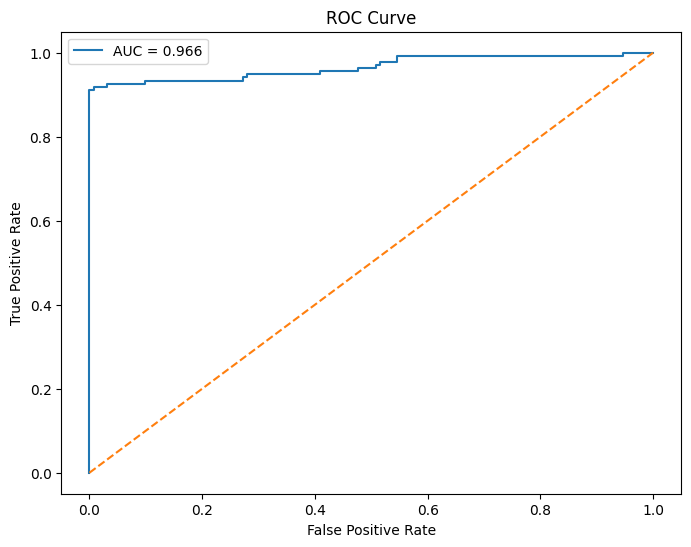

In [49]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png")

plt.show()

In [50]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

In [51]:
threshold_results = []
for threshold in thresholds:
    predictions = (y_pred_proba >= threshold).astype(int)
    precision = precision_score(y_clf_test, predictions)
    recall = recall_score(y_clf_test, predictions)
    f1 = f1_score(y_clf_test, predictions)
    threshold_results.append([threshold, precision, recall, f1])
threshold_table = pd.DataFrame(threshold_results,columns=["Threshold","Precision","Recall","F1"])

threshold_table

,Threshold,Precision,Recall,F1
0,0.3,0.775758,0.941176,0.850498
1,0.4,0.841060,0.933824,0.885017
2,0.5,0.894366,0.933824,0.913669
3,0.6,0.984252,0.919118,0.950570
4,0.7,1.000000,0.838235,0.912000


In [52]:
best_threshold = threshold_table.loc[threshold_table["F1"].idxmax()]

best_threshold

,3
Threshold,0.600000
Precision,0.984252
Recall,0.919118
F1,0.950570


In [53]:
logistic_regularized = LogisticRegression(C=0.01,max_iter=1000)
logistic_regularized.fit(X_train_clf_scaled,y_clf_train)

LogisticRegression(C=0.01, max_iter=1000)

In [54]:
regularized_predictions = logistic_regularized.predict(X_test_clf_scaled)
regularized_proba = logistic_regularized.predict_proba(X_test_clf_scaled)[:,1]

In [55]:
regularized_precision = precision_score(y_clf_test,regularized_predictions)

regularized_recall = recall_score(y_clf_test,regularized_predictions)

regularized_auc = roc_auc_score(y_clf_test,regularized_proba)

print("Precision:", regularized_precision)
print("Recall:", regularized_recall)
print("AUC:", regularized_auc)

Precision: 0.9064748201438849
Recall: 0.9264705882352942
AUC: 0.9651849376114082


In [58]:
comparison = pd.DataFrame({
    "Model":["Baseline (C=1.0)","Regularized (C=0.01)"],
    "Precision":[precision_score(y_clf_test,y_pred_clf),regularized_precision],
    "Recall":[recall_score(y_clf_test,y_pred_clf),regularized_recall],
    "AUC":[auc,regularized_auc]
})

comparison

,Model,Precision,Recall,AUC
0,Baseline (C=1.0),0.894366,0.933824,0.965909
1,Regularized (C=0.01),0.906475,0.926471,0.965185


In [59]:
bootstrap_differences = []

for i in range(500):
    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
)
    auc1 = roc_auc_score(y_clf_test.iloc[indices],y_pred_proba[indices])
    auc2 = roc_auc_score(y_clf_test.iloc[indices],regularized_proba[indices])
    bootstrap_differences.append(auc1-auc2)

In [60]:
mean_difference = np.mean(bootstrap_differences)
lower = np.percentile(bootstrap_differences,2.5)
upper = np.percentile(bootstrap_differences,97.5)

print("Mean Difference :", mean_difference)
print("Lower CI :", lower)
print("Upper CI :", upper)

Mean Difference : 0.0007320600717964871
Lower CI : -0.0012890242720888954
Upper CI : 0.0030672392851572804
